# Analytic branch coherence for basin pullback

This notebook explains the analytic part missing after the finite torsor formalization.

The algebraic root choices are now formalized in Lean: at escape time $N$, the solutions of

$$
w^{2^N}=\Phi_\infty(f^N(z))
$$

form a torsor under $\mu_{2^N}$. The remaining problem is not algebraic existence of roots. It is selecting a compatible root **as a holomorphic function of $z$**.

The Lean target expressing this missing basin-extension theorem is:

```lean
Quadratic.PrincipalPullbackCoherentDataFor (2 : ℂ)
```

The key analytic question is: when can we choose $w(z)$ locally holomorphically so that

$$
w(z)^{2^N}=\Phi_\infty(f^N(z))?
$$


In [1]:
import cmath
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120

def principal_root(A, degree):
    return cmath.exp(cmath.log(A) / degree)

def continued_root_along_path(A_path, degree):
    """Continuous branch of A^(1/degree) along a sampled path, via phase unwrapping."""
    radii = np.abs(A_path) ** (1 / degree)
    phases = np.unwrap(np.angle(A_path)) / degree
    return radii * np.exp(1j * phases)

def plot_complex_path(ax, values, label, color, marker=None, linewidth=2):
    ax.plot(values.real, values.imag, color=color, label=label, linewidth=linewidth)
    if marker is not None:
        ax.scatter([values[0].real], [values[0].imag], color=color, marker=marker, s=80, label=f'{label} start')
        ax.scatter([values[-1].real], [values[-1].imag], color=color, marker='x', s=80, label=f'{label} end')


## Local branch selection versus global monodromy

For a nonzero holomorphic function $A(z)$, a local holomorphic $d$-th root exists near any point where $A(z)\neq 0$. Locally, there is no problem.

The obstruction appears when continuing the root around loops. If the loop $A(z)$ winds once around $0$, then a continued $d$-th root comes back multiplied by

$$
\exp(2\pi i/d).
$$

For $d=2$, the square root changes sign. For $d=2^N$, it is multiplied by a $2^N$-th root of unity.

So coherent basin pullback needs a no-monodromy statement: the branch selected near infinity must continue through the basin without accumulating a nontrivial root-of-unity factor.

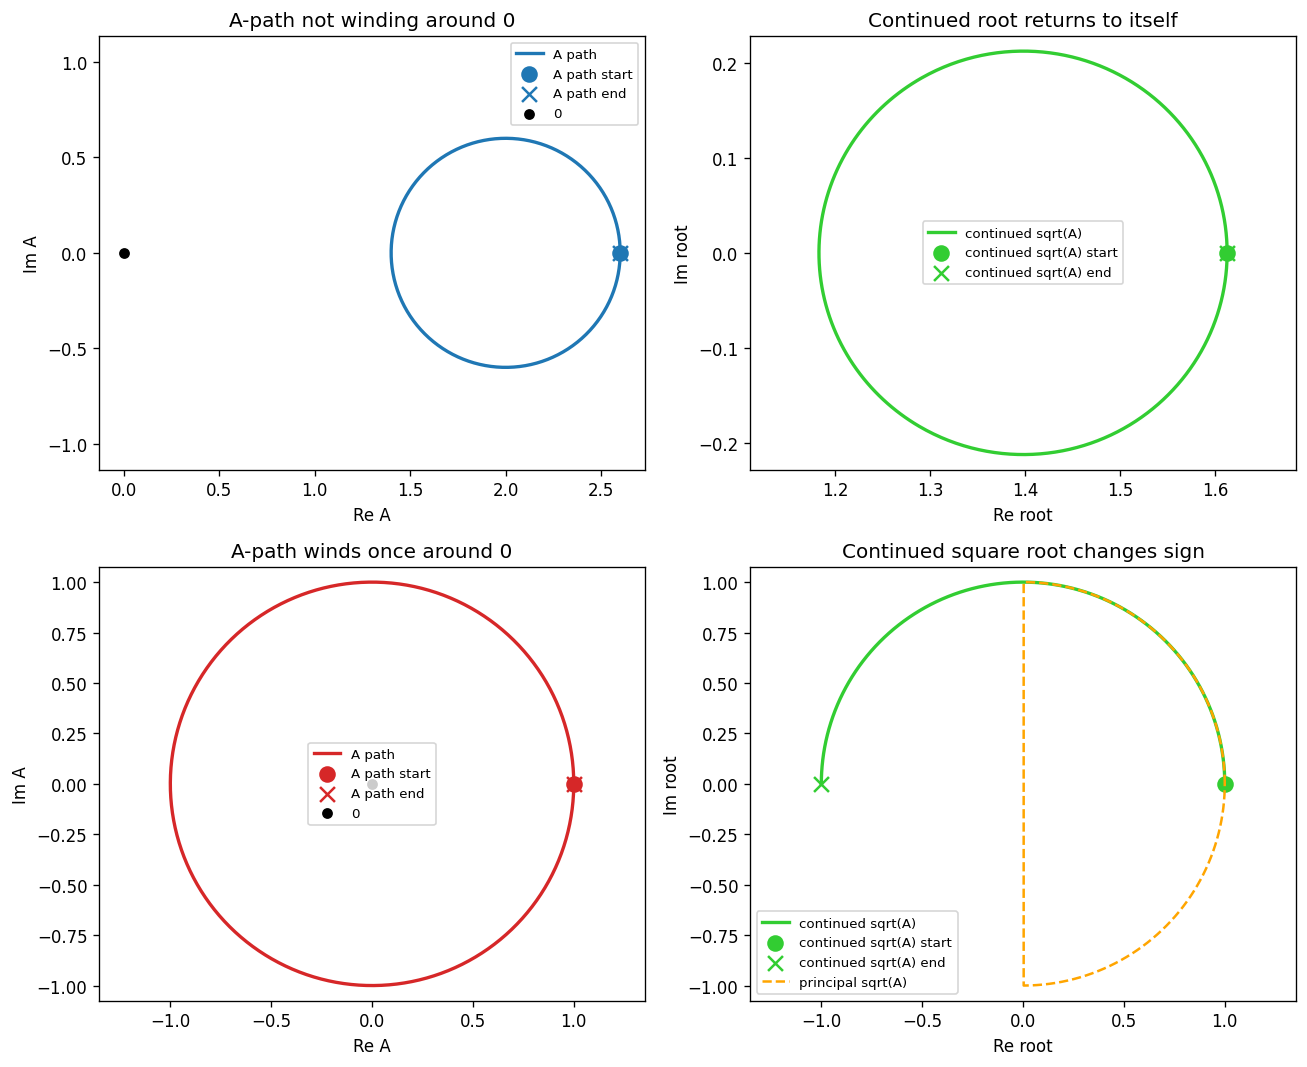

Non-winding loop: start/end continued root ratio = (0.9999999999999999-2.8261079980323534e-17j)
Winding loop:     start/end continued root ratio = (-1+1.2246467991473532e-16j)


In [2]:
theta = np.linspace(0, 2*np.pi, 500)

def loop(center, radius):
    return center + radius * np.exp(1j * theta)

A_nonwinding = loop(2.0 + 0j, 0.6)   # does not surround 0
A_winding = loop(0.0 + 0j, 1.0)      # surrounds 0 once

degree = 2
root_nonwinding_cont = continued_root_along_path(A_nonwinding, degree)
root_winding_cont = continued_root_along_path(A_winding, degree)
root_winding_principal = np.array([principal_root(a, degree) for a in A_winding])

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

ax = axes[0, 0]
plot_complex_path(ax, A_nonwinding, 'A path', 'tab:blue', marker='o')
ax.scatter([0], [0], color='black', s=30, label='0')
ax.set_title('A-path not winding around 0')
ax.set_xlabel('Re A')
ax.set_ylabel('Im A')
ax.axis('equal')
ax.legend(fontsize=8)

ax = axes[0, 1]
plot_complex_path(ax, root_nonwinding_cont, 'continued sqrt(A)', 'limegreen', marker='o')
ax.set_title('Continued root returns to itself')
ax.set_xlabel('Re root')
ax.set_ylabel('Im root')
ax.axis('equal')
ax.legend(fontsize=8)

ax = axes[1, 0]
plot_complex_path(ax, A_winding, 'A path', 'tab:red', marker='o')
ax.scatter([0], [0], color='black', s=30, label='0')
ax.set_title('A-path winds once around 0')
ax.set_xlabel('Re A')
ax.set_ylabel('Im A')
ax.axis('equal')
ax.legend(fontsize=8)

ax = axes[1, 1]
plot_complex_path(ax, root_winding_cont, 'continued sqrt(A)', 'limegreen', marker='o')
ax.plot(root_winding_principal.real, root_winding_principal.imag, color='orange', linestyle='--', label='principal sqrt(A)')
ax.set_title('Continued square root changes sign')
ax.set_xlabel('Re root')
ax.set_ylabel('Im root')
ax.axis('equal')
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

print('Non-winding loop: start/end continued root ratio =', root_nonwinding_cont[-1] / root_nonwinding_cont[0])
print('Winding loop:     start/end continued root ratio =', root_winding_cont[-1] / root_winding_cont[0])


## Chosen strategy: trivialize the torsor tower

The group-theoretic formalization says that, for each escape time $N$, the possible pullback values form a torsor

$$
T_N(z)=\{w:w^{2^N}=\Phi_\infty(f^N(z))\}
$$

under the finite group $\mu_{2^N}$.

The chosen proof strategy is:

1. Use the normalized near-infinity coordinate to select a basepoint in the torsor whenever $z$ is already in the outside region.
2. For general basin points, transport this basepoint backward through the inverse system
   $$
   \cdots \to T_{N+1}(z) \to T_N(z) \to \cdots
   $$
   whose group transitions are $\zeta\mapsto\zeta^2$.
3. Prove that analytic continuation along any basin path preserves the selected basepoint.
4. Conclude that the principal pullback candidate is independent of the escape time and locally holomorphic.

In Lean terms, the finite torsor algebra is already checked. The remaining obstruction is to prove that the induced monodromy representation is trivial:

$$
\rho_N:\pi_1(U_\infty,z_0)\to \mu_{2^N},
\qquad
\rho_N(\gamma)=1
$$

for all relevant $N$ and loops $\gamma$.

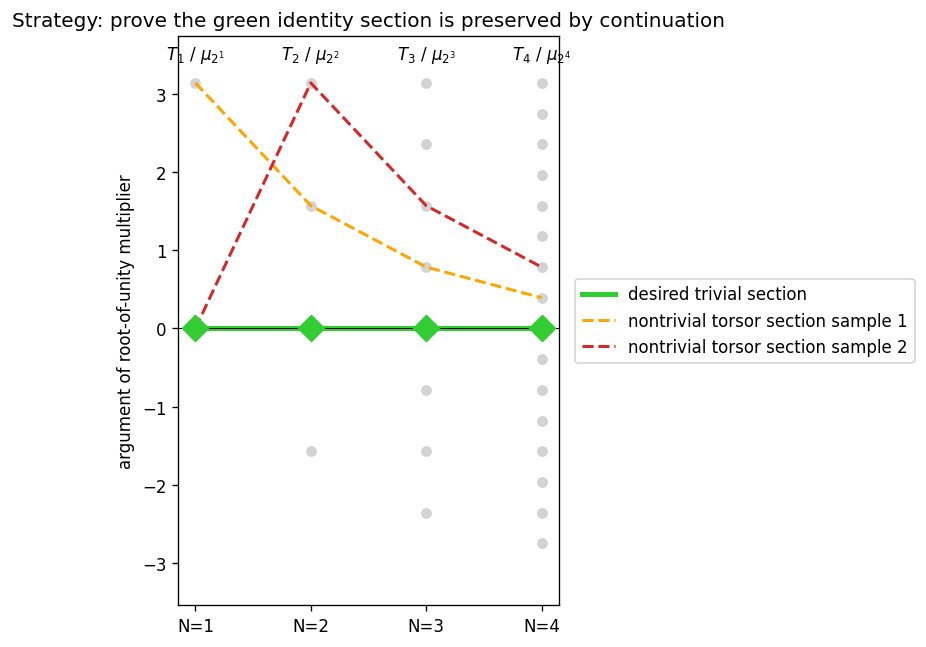

Green = the target coherent choice: multiplier 1 at every level.
Dashed = possible nontrivial torsor sections; the proof must rule these out as monodromy.


In [3]:
def roots_of_unity(k):
    return np.array([cmath.exp(2j * math.pi * j / (2**k)) for j in range(2**k)])

# Visual model of the torsor tower and the desired trivial section.
levels = [1, 2, 3, 4]
fig, ax = plt.subplots(figsize=(9, 5.5))

x_positions = np.arange(len(levels))
selected_y = []
for idx, k in enumerate(levels):
    roots = roots_of_unity(k)
    # Spread the roots vertically by their argument.
    ys = np.angle(roots)
    xs = np.full_like(ys, x_positions[idx], dtype=float)
    ax.scatter(xs, ys, s=30, color='lightgray')
    # selected compatible basepoint is the identity root at every level
    selected_y.append(0.0)
    ax.scatter([x_positions[idx]], [0.0], color='limegreen', s=120, marker='D', zorder=5)
    ax.text(x_positions[idx], 3.45, f'$T_{{{k}}}$ / $\\mu_{{2^{k}}}$', ha='center')

# Draw compatible selected section.
ax.plot(x_positions, selected_y, color='limegreen', linewidth=3, label='desired trivial section')

# Draw examples of nontrivial branches/monodromy paths.
for offset, color in [(1, 'orange'), (2, 'tab:red')]:
    ys = []
    for k in levels:
        roots = roots_of_unity(k)
        ys.append(np.angle(roots[offset % len(roots)]))
    ax.plot(x_positions, ys, '--', color=color, linewidth=1.8, label=f'nontrivial torsor section sample {offset}')

ax.set_xticks(x_positions, [f'N={k}' for k in levels])
ax.set_ylim(-math.pi - 0.4, math.pi + 0.6)
ax.set_ylabel('argument of root-of-unity multiplier')
ax.set_title('Strategy: prove the green identity section is preserved by continuation')
ax.axhline(0, color='black', linewidth=0.6)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
fig.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()

print('Green = the target coherent choice: multiplier 1 at every level.')
print('Dashed = possible nontrivial torsor sections; the proof must rule these out as monodromy.')

## What this means for escape-time independence

In the Böttcher pullback problem, the function being rooted is

$$
A_N(z)=\Phi_\infty(f^N(z)).
$$

At each $N$, roots of $A_N(z)$ form a torsor under $\mu_{2^N}$. The group-theoretic transition says that compatible choices must map correctly under squaring. The analytic obstruction says that the chosen root may still change by monodromy when $z$ moves around a loop.

Formally, for a loop $\gamma$ in the basin, analytic continuation of a selected root may return as

$$
\zeta\,w(z),\qquad \zeta\in\mu_{2^N}.
$$

The missing theorem is that this monodromy factor is always $1$ for the normalized pullback branch.

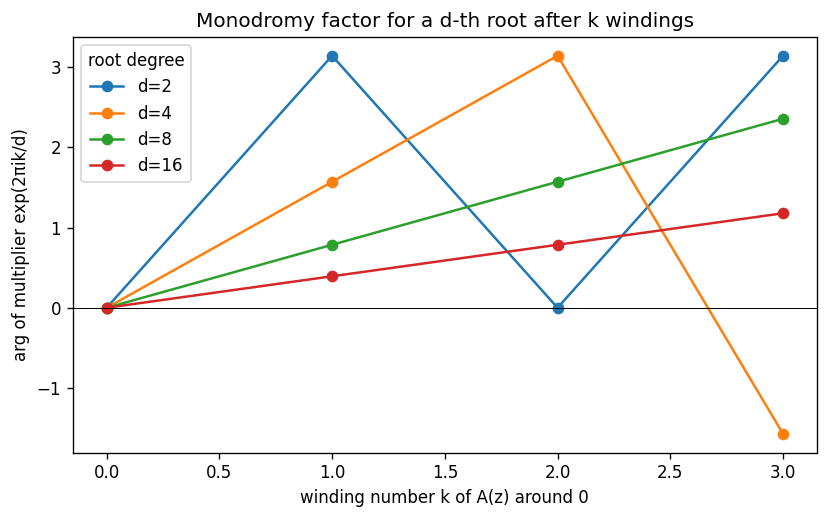

If d=2^N and winding k is not divisible by d, continuation returns a different root.


In [4]:
degrees = [2, 4, 8, 16]
windings = [0, 1, 2, 3]

fig, ax = plt.subplots(figsize=(8, 4.5))
for d in degrees:
    factors = [cmath.exp(2j * math.pi * k / d) for k in windings]
    angles = [cmath.phase(x) for x in factors]
    ax.plot(windings, angles, 'o-', label=f'd={d}')
ax.axhline(0, color='black', linewidth=0.6)
ax.set_title('Monodromy factor for a d-th root after k windings')
ax.set_xlabel('winding number k of A(z) around 0')
ax.set_ylabel('arg of multiplier exp(2πik/d)')
ax.legend(title='root degree')
plt.show()

print('If d=2^N and winding k is not divisible by d, continuation returns a different root.')


## Clear obstruction

The obstruction is not that roots fail to exist. They always exist algebraically.

The obstruction is that analytic continuation of a chosen local branch may return to a different element of the same root torsor. In symbols, continuation around a loop $\gamma$ can transform a chosen branch $w_N(z)$ into

$$
w_N(z)\longmapsto \rho_N(\gamma)\,w_N(z),
\qquad
\rho_N(\gamma)\in\mu_{2^N}.
$$

To finish the basin extension, we must prove

$$
\rho_N(\gamma)=1
$$

for every loop relevant to the basin extension. This is exactly what is missing from the current Lean development.

If some loop has $\rho_N(\gamma)\ne 1$, then the pullback value depends on the path or escape iterate, and the principal pullback candidate cannot define a single-valued holomorphic Böttcher coordinate on the basin.

So the proof target is now precise:

> show that the normalized near-infinity branch trivializes the inverse system of root-choice torsors over the whole basin.

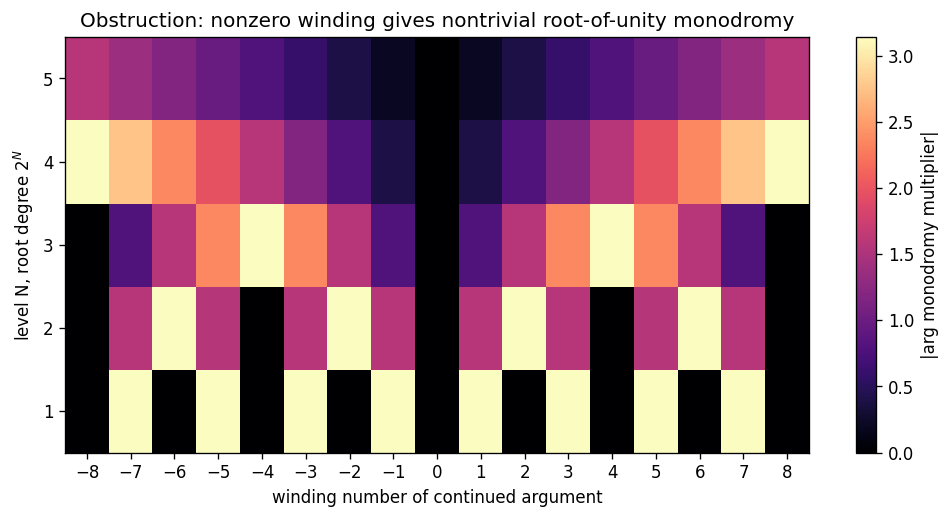

Dark cells are trivial monodromy. Bright cells are branch changes.
The theorem needs all basin continuation loops to land in the dark/trivial case.


In [5]:
# Monodromy factors for different winding numbers and root levels.
levels = [1, 2, 3, 4, 5]
windings = np.arange(-8, 9)
Z = np.zeros((len(levels), len(windings)))

for i, N in enumerate(levels):
    d = 2**N
    for j, k in enumerate(windings):
        factor = cmath.exp(2j * math.pi * k / d)
        Z[i, j] = abs(cmath.phase(factor))

fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(Z, aspect='auto', origin='lower', cmap='magma',
               extent=[windings[0]-0.5, windings[-1]+0.5, levels[0]-0.5, levels[-1]+0.5])
fig.colorbar(im, ax=ax, label='|arg monodromy multiplier|')
ax.set_xticks(windings)
ax.set_yticks(levels)
ax.set_xlabel('winding number of continued argument')
ax.set_ylabel('level N, root degree $2^N$')
ax.set_title('Obstruction: nonzero winding gives nontrivial root-of-unity monodromy')
plt.show()

print('Dark cells are trivial monodromy. Bright cells are branch changes.')
print('The theorem needs all basin continuation loops to land in the dark/trivial case.')

## Why an average or nearest rule is not the proof

A numerical rule can choose one point in each finite root cloud. But the theorem requires a holomorphic choice on neighborhoods and equality on overlaps.

The correct group-theoretic proof should look like this:

1. Define root-choice torsors $T_N(z)$ under $\mu_{2^N}$.
2. Define transition maps $T_{N+1}(z)\to T_N(z)$ induced by squaring compatibility.
3. Use the near-infinity normalization to choose a basepoint when $z$ is already outside.
4. Prove analytic continuation of this basepoint along basin paths has trivial monodromy.
5. Conclude a globally well-defined holomorphic basin coordinate.

The finite torsor algebra is already formalized in Lean. The missing theorem is step 4.